In [44]:
import pandas as pd

In [45]:
df = pd.read_csv('./data/IndianWeatherRepository.csv')
cols = df.columns.tolist()
print(cols)

['country', 'location_name', 'region', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


In [46]:
# Numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric Columns:\n", numeric_cols)
print("\nCategorical Columns:\n", categorical_cols)

Numeric Columns:
 Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='object')

Categorical Columns:
 Index(['country', 'location_name', 'region', 'timezone', 'last_updated',
       'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase'],
      dtype='object')


In [47]:
print("Number of Numeric Features:", len(numeric_cols))
print("Number of Categorical Features:", len(categorical_cols))

Number of Numeric Features: 30
Number of Categorical Features: 12


In [48]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].nunique(), "unique values")


Column: country
1 unique values

Column: location_name
552 unique values

Column: region
33 unique values

Column: timezone
3 unique values

Column: last_updated
868 unique values

Column: condition_text
50 unique values

Column: wind_direction
16 unique values

Column: sunrise
177 unique values

Column: sunset
183 unique values

Column: moonrise
1441 unique values

Column: moonset
1441 unique values

Column: moon_phase
8 unique values


In [49]:
# Try converting columns to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')

# Check again
print(df.dtypes)

country                                 object
location_name                           object
region                                  object
latitude                               float64
longitude                              float64
timezone                                object
last_updated_epoch                       int64
last_updated                    datetime64[ns]
temperature_celsius                    float64
temperature_fahrenheit                 float64
condition_text                          object
wind_mph                               float64
wind_kph                               float64
wind_degree                              int64
wind_direction                          object
pressure_mb                            float64
pressure_in                            float64
precip_mm                              float64
precip_in                              float64
humidity                                 int64
cloud                                    int64
feels_like_ce

In [50]:
low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() < 10]

print("Low Cardinality Columns:\n", low_cardinality_cols)

Low Cardinality Columns:
 ['country', 'timezone', 'moon_phase']


In [51]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Unique Values': df.nunique(),
    'Missing Values': df.isnull().sum()
})

print(summary)

                                                    Column       Data Type  \
country                                            country          object   
location_name                                location_name          object   
region                                              region          object   
latitude                                          latitude         float64   
longitude                                        longitude         float64   
timezone                                          timezone          object   
last_updated_epoch                      last_updated_epoch           int64   
last_updated                                  last_updated  datetime64[ns]   
temperature_celsius                    temperature_celsius         float64   
temperature_fahrenheit              temperature_fahrenheit         float64   
condition_text                              condition_text          object   
wind_mph                                          wind_mph      

In [52]:
# Drop useless column
df.drop(columns=['country'], inplace=True)

# Drop redundant columns
df.drop(columns=[
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'visibility_miles',
    'gust_mph'
], inplace=True)

# Convert datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Extract time features
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month

# Drop original timestamp
df.drop(columns=['last_updated', 'last_updated_epoch'], inplace=True)

# Drop high-cardinality column
df.drop(columns=['location_name'], inplace=True)

# Log transform pollution features
import numpy as np

pollution_cols = [
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide'
]

for col in pollution_cols:
    df[col] = np.log1p(df[col])

In [53]:
# Average cloud cover for each weather condition
cloud_by_condition = df.groupby('condition_text')['cloud'].mean().sort_values()

print(cloud_by_condition)

condition_text
Clear                                            5.158948
Clear                                            5.794116
Sunny                                           13.044041
Mist                                            33.751054
Partly Cloudy                                   37.583333
Partly Cloudy                                   39.035813
Partly cloudy                                   39.379169
Thundery outbreaks possible                     53.493671
Thundery outbreaks in nearby                    58.363636
Fog                                             59.816559
Overcast                                        62.455567
Patchy snow possible                            65.600000
Patchy heavy snow                               67.333333
Patchy light snow in area with thunder          67.750000
Heavy rain at times                             68.250000
Patchy light drizzle                            68.953191
Patchy light rain                               70.155405

In [54]:
from scipy.stats import f_oneway

groups = [group['cloud'].values for name, group in df.groupby('condition_text')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 6637.42954497229
p-value: 0.0


<Figure size 640x480 with 0 Axes>

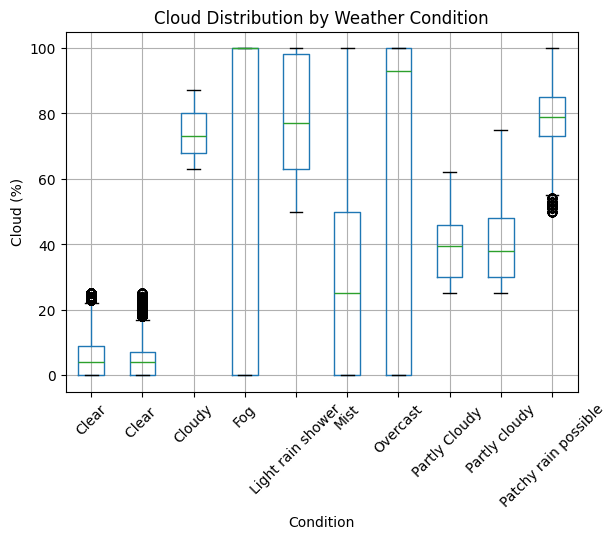

In [55]:
import matplotlib.pyplot as plt

# Top 10 most frequent conditions (to avoid clutter)
top_conditions = df['condition_text'].value_counts().head(10).index

subset = df[df['condition_text'].isin(top_conditions)]

plt.figure()
subset.boxplot(column='cloud', by='condition_text', rot=45)
plt.title("Cloud Distribution by Weather Condition")
plt.suptitle("")
plt.xlabel("Condition")
plt.ylabel("Cloud (%)")
plt.show()

In [56]:
# Encode categorical variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['condition_encoded'] = le.fit_transform(df['condition_text'])

# Correlation
correlation = df[['cloud', 'condition_encoded']].corr()

print(correlation)

                      cloud  condition_encoded
cloud              1.000000           0.643911
condition_encoded  0.643911           1.000000


In [57]:
from scipy.stats import f_oneway

groups = [group['cloud'].values for name, group in df.groupby('condition_text')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 6637.42954497229
p-value: 0.0


In [58]:
cloud_by_condition = df.groupby('condition_text')['cloud'].mean().sort_values()
print(cloud_by_condition)

condition_text
Clear                                            5.158948
Clear                                            5.794116
Sunny                                           13.044041
Mist                                            33.751054
Partly Cloudy                                   37.583333
Partly Cloudy                                   39.035813
Partly cloudy                                   39.379169
Thundery outbreaks possible                     53.493671
Thundery outbreaks in nearby                    58.363636
Fog                                             59.816559
Overcast                                        62.455567
Patchy snow possible                            65.600000
Patchy heavy snow                               67.333333
Patchy light snow in area with thunder          67.750000
Heavy rain at times                             68.250000
Patchy light drizzle                            68.953191
Patchy light rain                               70.155405

In [59]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Optional: drop target if you want separate analysis
# numeric_df = numeric_df.drop(columns=['cloud'])

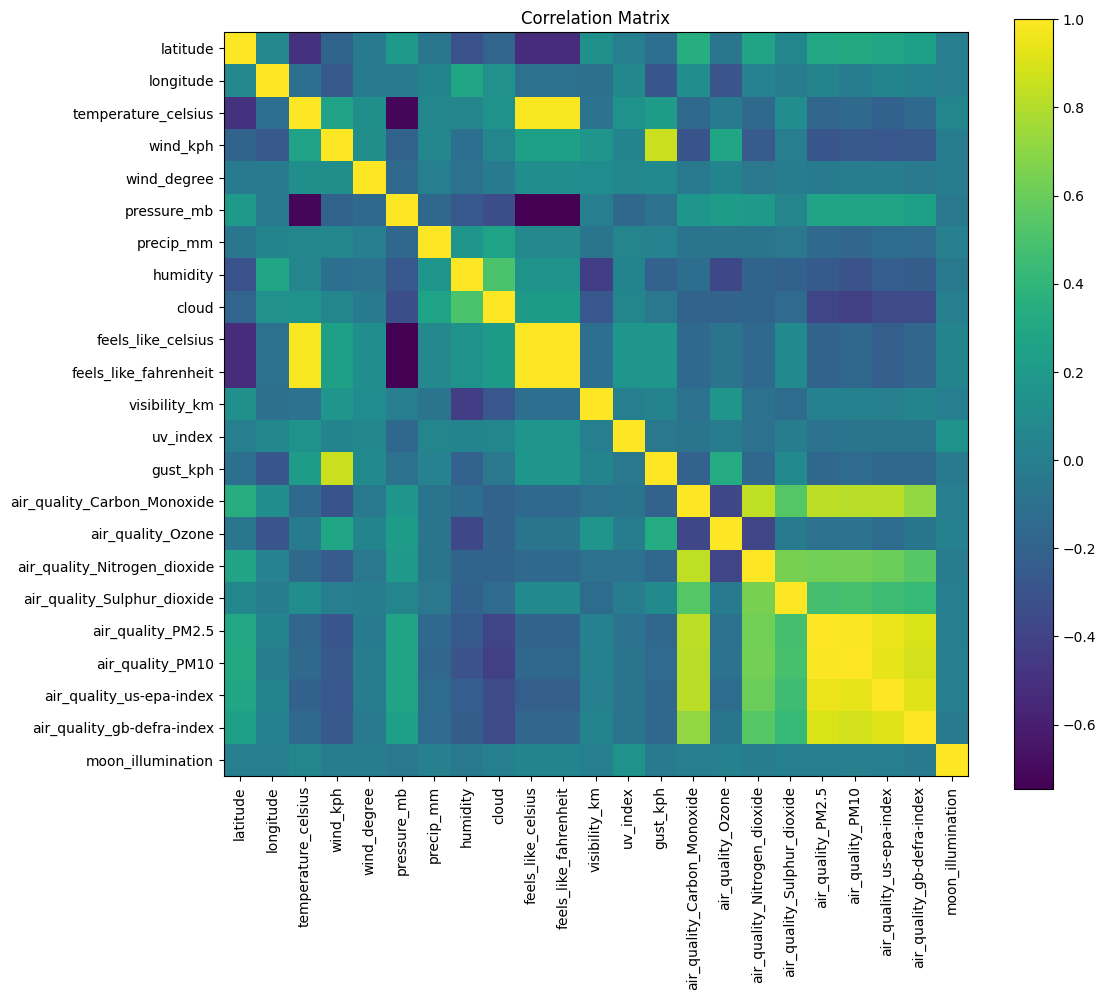

In [60]:
corr_matrix = numeric_df.corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix)

plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.show()

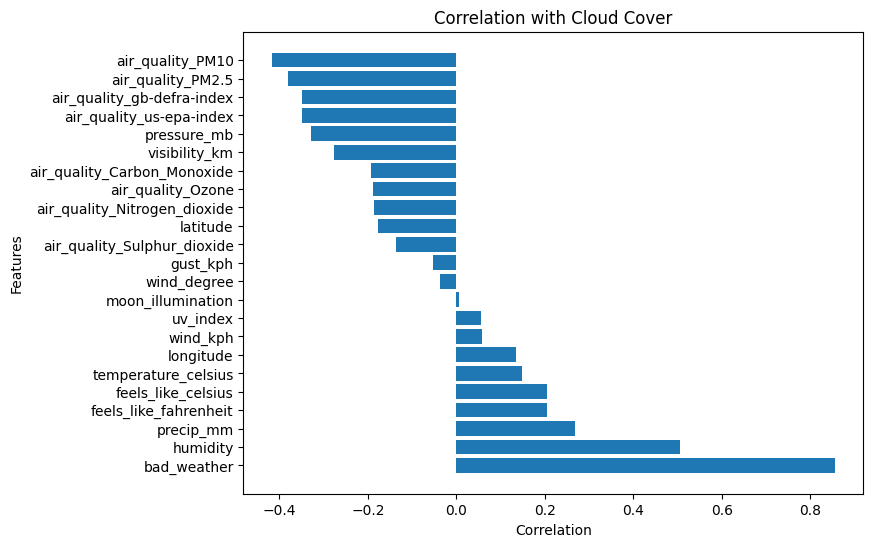

In [61]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df['bad_weather'] = df['condition_text'].map(cloud_by_condition)
corr_matrix = numeric_df.corr()

cloud_corr = corr_matrix['cloud'].sort_values(ascending=False)
cloud_corr = cloud_corr.drop('cloud')

plt.figure(figsize=(8, 6))
plt.barh(cloud_corr.index, cloud_corr.values)
plt.title("Correlation with Cloud Cover")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

In [62]:
df = pd.read_csv('./data/IndianWeatherRepository.csv')

In [64]:
from sklearn.preprocessing import StandardScaler

features = ['temperature_celsius', 'humidity', 'pressure_mb', 'air_quality_PM2.5', 'moon_illumination', 'cloud']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

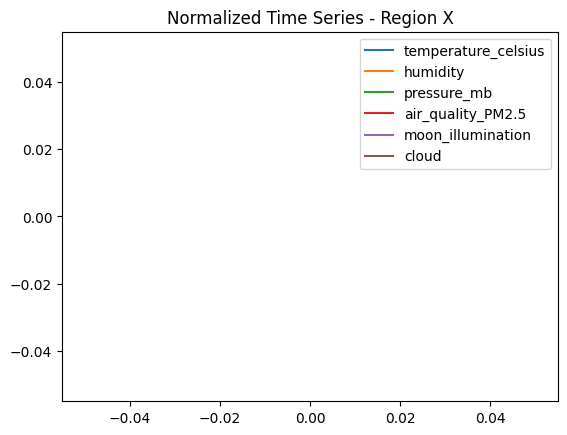

In [65]:
import matplotlib.pyplot as plt

region_df = df_scaled[df_scaled['region'] == 'YourRegion']

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title('Normalized Time Series - Region X')
plt.show()

In [ ]:
print(df['region'].unique())

['Madhya Pradesh' 'Uttar Pradesh' 'Orissa' 'Rajasthan' 'Gujarat'
 'Himachal Pradesh' 'Chhattisgarh' 'Jammu and Kashmir' 'Daman and Diu'
 'Dadra and Nagar Haveli' 'Andhra Pradesh' 'Jharkhand' 'Bihar'
 'West Bengal' 'Maharashtra' 'Haryana' 'Chandigarh' 'Goa'
 'Andaman and Nicobar Islands' 'Arunachal Pradesh' 'Assam' 'Puducherry'
 'Kerala' 'Mizoram' 'Manipur' 'Nagaland' 'Tripura' 'Karnataka'
 'Uttarakhand' 'Lakshadweep' 'Punjab' 'Tamil Nadu' 'Delhi']


In [66]:
region_name = 'Assam'

In [67]:
region_df = df[df['region'] == region_name]

print(region_df.shape)   # should NOT be (0, ...)
print(region_df.head())

(4568, 42)
    country location_name region  latitude  longitude      timezone  \
191   India      Goalpara  Assam     26.17      90.62  Asia/Kolkata   
192   India       Nalbari  Assam     26.42      91.43  Asia/Kolkata   
193   India        Dhubri  Assam     26.03      89.97  Asia/Kolkata   
194   India     Karimganj  Assam     24.87      92.35    Asia/Dhaka   
195   India      Tinsukia  Assam     27.50      95.37  Asia/Kolkata   

     last_updated_epoch      last_updated  temperature_celsius  \
191          1693286100  2023-08-29 10:45                 30.9   
192          1693286100  2023-08-29 10:45                 30.0   
193          1693286100  2023-08-29 10:45                 31.8   
194          1693286100  2023-08-29 11:15                 32.0   
195          1693286100  2023-08-29 10:45                 30.0   

     temperature_fahrenheit  ... air_quality_PM2.5  air_quality_PM10  \
191                    87.6  ...              54.2              59.7   
192                  

In [ ]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

In [84]:
features = ['temperature_celsius', 'humidity',  'air_quality_PM2.5', 'moon_illumination', 'cloud']

region_df = region_df.dropna(subset=features)

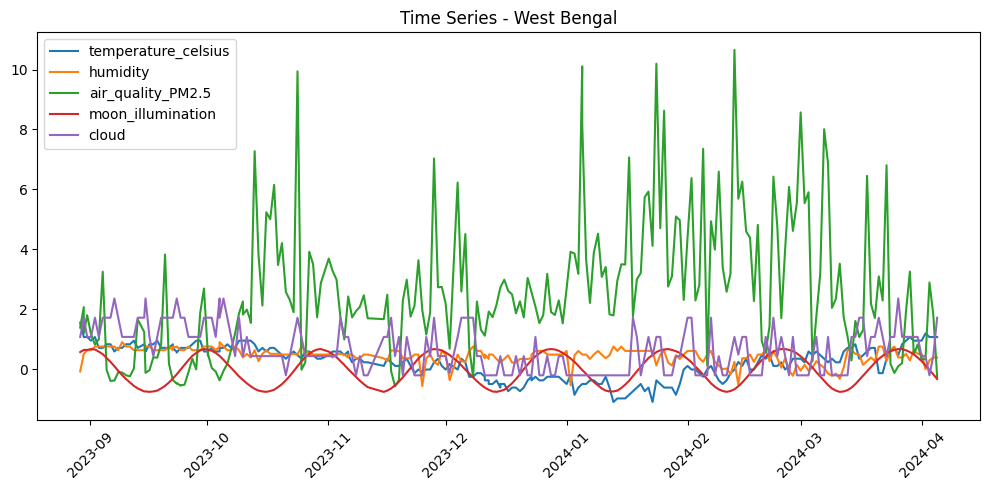

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title(f'Time Series - {region_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

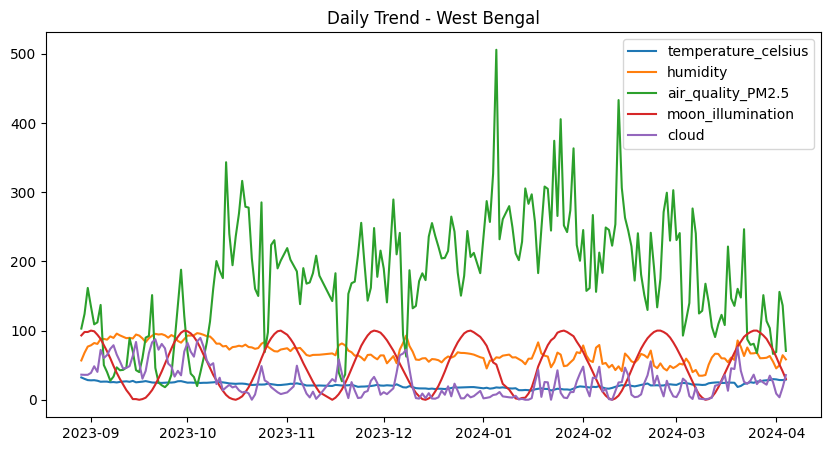

In [86]:
region_df = df[df['region'] == region_name].copy()

# ensure last_updated is datetime, set as index and then resample
region_df['last_updated'] = pd.to_datetime(region_df['last_updated'], errors='coerce')
region_df = region_df.set_index('last_updated').resample('D').mean(numeric_only=True)

region_df = region_df.dropna(subset=features)
plt.figure(figsize=(10,5))
for col in features:
    plt.plot(region_df.index, region_df[col], label=col)

plt.legend()
plt.title(f'Daily Trend - {region_name}')
plt.show()

In [82]:
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

# Features to normalize
features = ['temperature_celsius', 'humidity', 'pressure_mb', 'air_quality_PM2.5', 'moon_illumination', 'cloud']

# Ensure datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Sort data (important for time series)
df = df.sort_values('last_updated')

# Apply Robust Scaling
scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

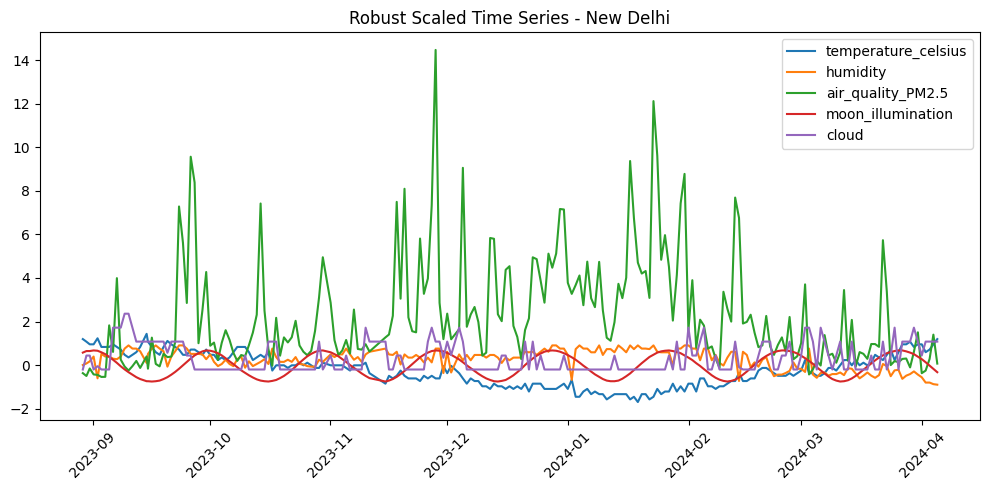

In [102]:
region_name = 'West Bengal'  # change as needed
location_name = 'New Delhi'  # change as needed

region_df = df_scaled[df_scaled['location_name'] == location_name].copy()

# Drop NaNs just in case
region_df = region_df.dropna(subset=features)

# Sort by time
region_df = region_df.sort_values('last_updated')

plt.figure(figsize=(10,5))

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title(f'Robust Scaled Time Series - {location_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

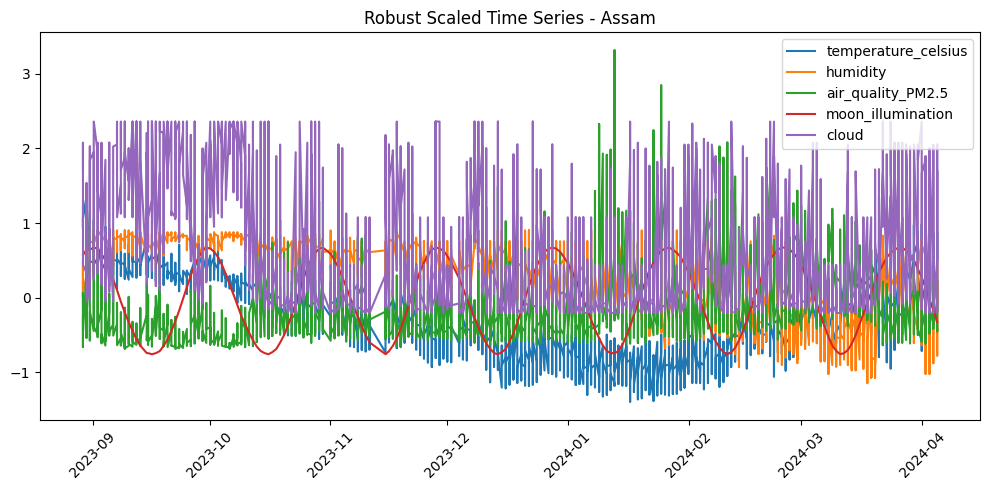

In [92]:
region_name = 'Assam'  # change as needed

region_df = df_scaled[df_scaled['region'] == region_name].copy()

# Drop NaNs just in case
region_df = region_df.dropna(subset=features)

# Sort by time
region_df = region_df.sort_values('last_updated')

plt.figure(figsize=(10,5))

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title(f'Robust Scaled Time Series - {region_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

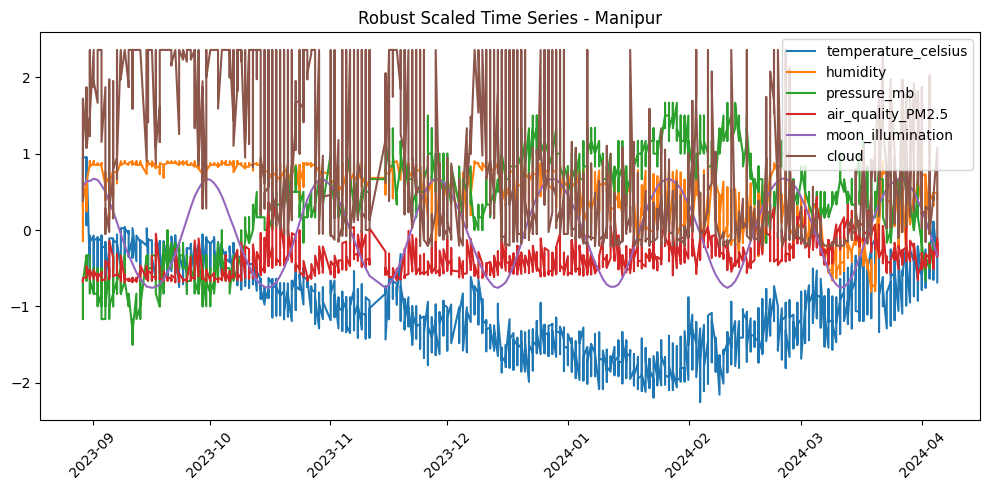

In [74]:
region_name = 'Manipur'  # change as needed

region_df = df_scaled[df_scaled['region'] == region_name].copy()

# Drop NaNs just in case
region_df = region_df.dropna(subset=features)

# Sort by time
region_df = region_df.sort_values('last_updated')

plt.figure(figsize=(10,5))

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title(f'Robust Scaled Time Series - {region_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

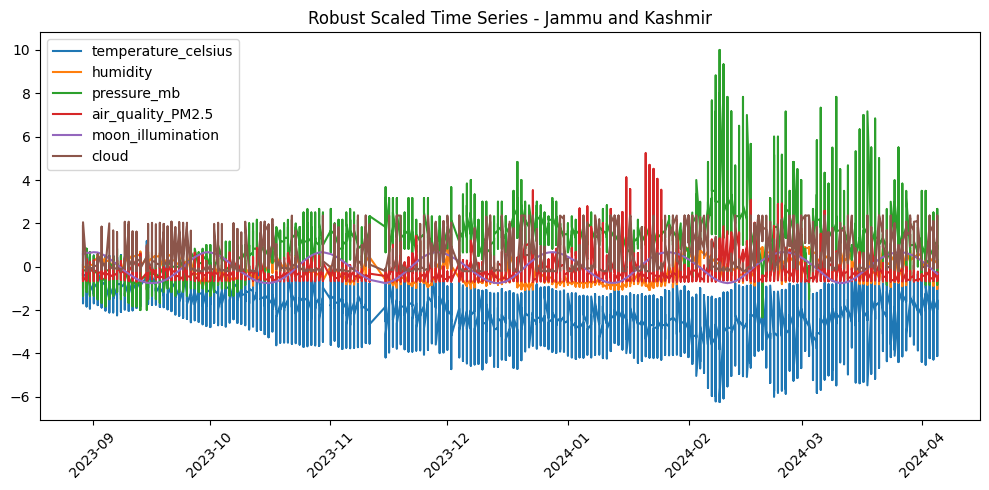

In [76]:
region_name = 'Jammu and Kashmir'  # change as needed

region_df = df_scaled[df_scaled['region'] == region_name].copy()

# Drop NaNs just in case
region_df = region_df.dropna(subset=features)

# Sort by time
region_df = region_df.sort_values('last_updated')

plt.figure(figsize=(10,5))

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title(f'Robust Scaled Time Series - {region_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

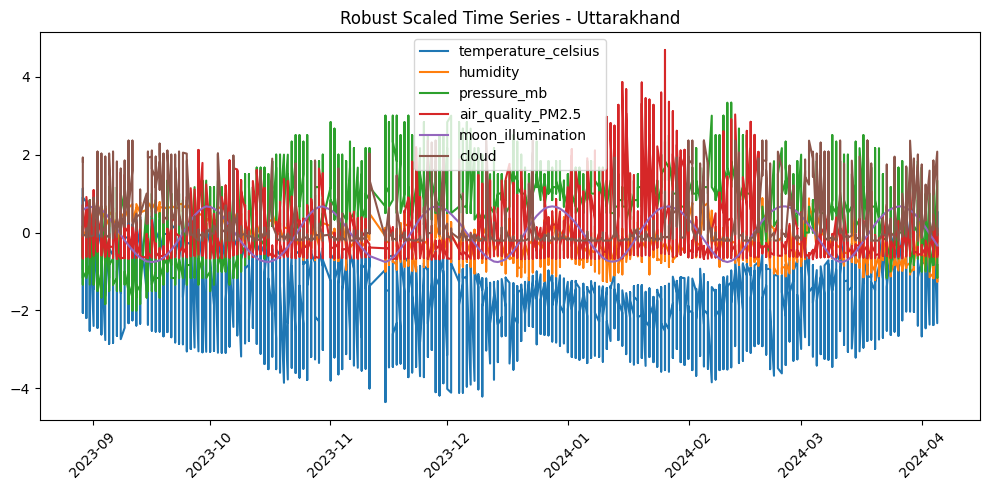

In [77]:
region_name = 'Uttarakhand'  # change as needed

region_df = df_scaled[df_scaled['region'] == region_name].copy()

# Drop NaNs just in case
region_df = region_df.dropna(subset=features)

# Sort by time
region_df = region_df.sort_values('last_updated')

plt.figure(figsize=(10,5))

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title(f'Robust Scaled Time Series - {region_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

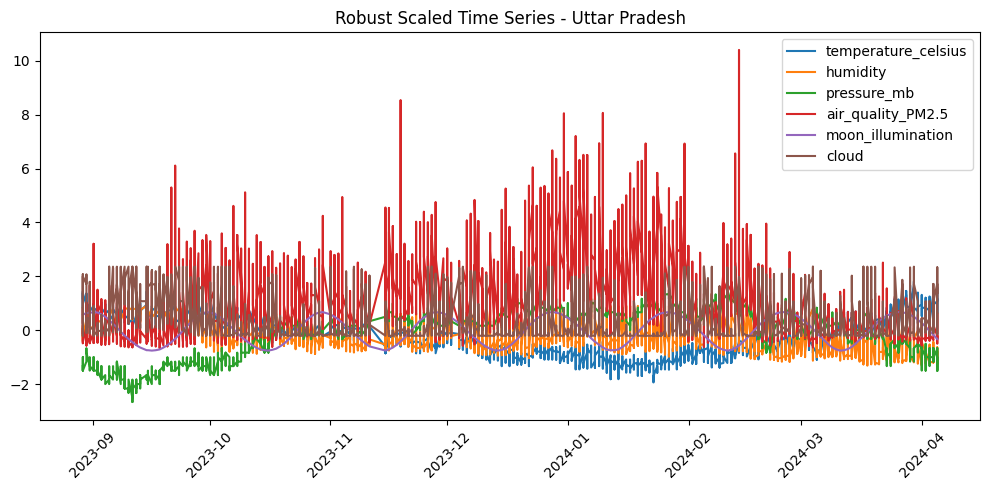

In [78]:
region_name = 'Uttar Pradesh'  # change as needed

region_df = df_scaled[df_scaled['region'] == region_name].copy()

# Drop NaNs just in case
region_df = region_df.dropna(subset=features)

# Sort by time
region_df = region_df.sort_values('last_updated')

plt.figure(figsize=(10,5))

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title(f'Robust Scaled Time Series - {region_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

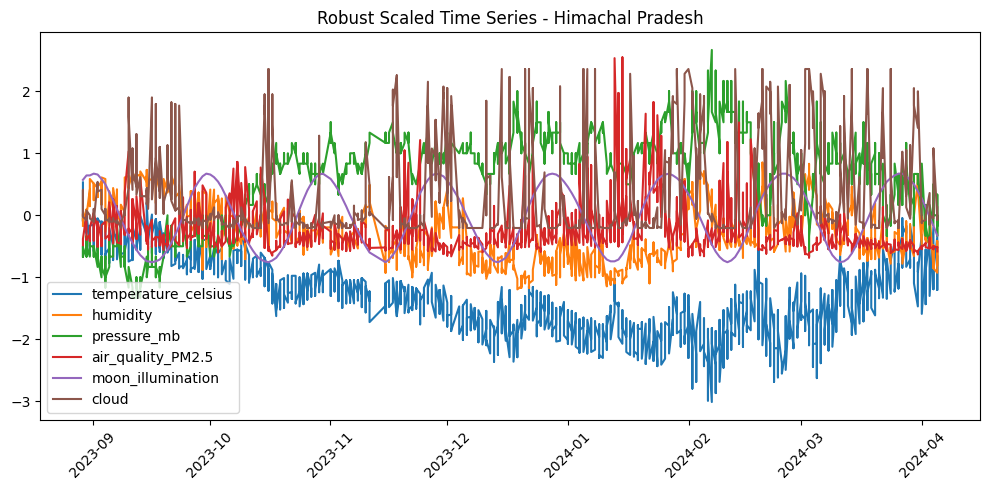

In [79]:
region_name = 'Himachal Pradesh'  # change as needed

region_df = df_scaled[df_scaled['region'] == region_name].copy()

# Drop NaNs just in case
region_df = region_df.dropna(subset=features)

# Sort by time
region_df = region_df.sort_values('last_updated')

plt.figure(figsize=(10,5))

for col in features:
    plt.plot(region_df['last_updated'], region_df[col], label=col)

plt.legend()
plt.title(f'Robust Scaled Time Series - {region_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()